# Purpose
Determine whether the raw sensor data is trustworthy enough to analyze.

In [13]:
%pip install pandas numpy seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import numpy as np
import pandas as pd
import seaborn as sns

In [15]:
db = pd.read_csv("../testing/csv_data_saving/csv/sensor_data.csv")
print(db)


                timestamp  gas_raw  temperature_c  humidity_percent  \
0     2026-09-23 16:27:19     1456          24.00              42.9   
1     2026-09-23 16:27:24     1692          24.00              42.9   
2     2026-09-23 16:27:29     1360          24.00              42.9   
3     2026-09-23 16:27:34     1085          23.50              42.9   
4     2026-09-23 16:27:39      913          24.00              42.8   
...                   ...      ...            ...               ...   
1197  2026-09-25 09:08:04      247          28.25              36.4   
1198  2026-09-25 09:08:09      249          27.50              36.5   
1199  2026-09-25 09:08:14      258          28.00              36.5   
1200  2026-09-25 09:08:19      247          27.50              36.5   
1201  2026-09-25 09:08:24      241          28.00              36.7   

      anomaly_detected threat_level      location  experiment_stage  \
0                 True         High      House_01               NaN   
1    

We are currently expecting the following columns: timestamp, gas_raw, temperature_c, humidity_percent, location, session_id

temporarily we will fill location and session_id manually until we have the permanent MQTT data storage system

In [16]:
db["location"] = "House_01"
db["session_id"] = "ESP32_01"

print(db)

                timestamp  gas_raw  temperature_c  humidity_percent  \
0     2026-09-23 16:27:19     1456          24.00              42.9   
1     2026-09-23 16:27:24     1692          24.00              42.9   
2     2026-09-23 16:27:29     1360          24.00              42.9   
3     2026-09-23 16:27:34     1085          23.50              42.9   
4     2026-09-23 16:27:39      913          24.00              42.8   
...                   ...      ...            ...               ...   
1197  2026-09-25 09:08:04      247          28.25              36.4   
1198  2026-09-25 09:08:09      249          27.50              36.5   
1199  2026-09-25 09:08:14      258          28.00              36.5   
1200  2026-09-25 09:08:19      247          27.50              36.5   
1201  2026-09-25 09:08:24      241          28.00              36.7   

      anomaly_detected threat_level  location  experiment_stage  \
0                 True         High  House_01               NaN   
1            

### Check for missing values

In [17]:
missing_values = db.isna().sum()
empty_values = db.astype("string").apply(lambda column: column.str.strip().eq("").sum())
missing_summary = pd.DataFrame({"missing": missing_values, "empty": empty_values})
print(missing_summary)

if missing_summary.to_numpy().sum() == 0:
    print("No missing or empty values found.")
else:
    print("Missing or empty values found.")

                  missing  empty
timestamp               0      0
gas_raw                 0      0
temperature_c           0      0
humidity_percent        0      0
anomaly_detected        0      0
threat_level            0      0
location                0      0
experiment_stage     1049      0
is_experiment           0      0
session_id              0      0
Missing or empty values found.


In [18]:
print(db.describe())

           gas_raw  temperature_c  humidity_percent
count  1202.000000    1202.000000       1202.000000
mean    196.944260      26.275790         40.583444
std     130.825774      10.282447          1.781518
min      37.000000      23.000000         36.400000
25%     123.000000      23.750000         39.600000
50%     134.000000      24.000000         40.100000
75%     256.000000      24.250000         41.000000
max    1692.000000     126.750000         47.600000


### Check sampling interval
Expected: 5s

In [19]:
timestamps = pd.to_datetime(db["timestamp"])
interval_seconds = timestamps.diff().dt.total_seconds()
unexpected_mask = interval_seconds.notna() & interval_seconds.ne(5)

unexpected_rows = pd.DataFrame({
    "previous_index": db.index.to_series().shift(1)[unexpected_mask].astype(int).to_numpy(),
    "current_index": db.index[unexpected_mask],
    "previous_csv_row": (db.index.to_series().shift(1)[unexpected_mask] + 2).astype(int).to_numpy(),
    "current_csv_row": db.index[unexpected_mask] + 2,
    "previous_timestamp": timestamps.shift(1)[unexpected_mask].to_numpy(),
    "current_timestamp": timestamps[unexpected_mask].to_numpy(),
    "interval_seconds": interval_seconds[unexpected_mask].to_numpy(),
})

print(f"Unexpected intervals: {len(unexpected_rows)}")
print(unexpected_rows.to_string(index=False))

Unexpected intervals: 78
 previous_index  current_index  previous_csv_row  current_csv_row  previous_timestamp   current_timestamp  interval_seconds
             24             25                26               27 2026-09-23 16:29:19 2026-09-23 16:29:25               6.0
             64             65                66               67 2026-09-23 16:32:40 2026-09-23 16:32:46               6.0
             97             98                99              100 2026-09-23 16:35:26 2026-09-23 16:36:06              40.0
             98             99               100              101 2026-09-23 16:36:06 2026-09-23 16:36:06               0.0
             99            100               101              102 2026-09-23 16:36:06 2026-09-23 16:36:07               1.0
            100            101               102              103 2026-09-23 16:36:07 2026-09-23 16:36:07               0.0
            101            102               103              104 2026-09-23 16:36:07 2026-09-23 16:36:07  

In [20]:
print(db[901:903])

               timestamp  gas_raw  temperature_c  humidity_percent  \
901  2026-09-23 17:42:52      129           24.0              40.2   
902  2026-09-23 17:42:52      128           24.0              40.0   

     anomaly_detected threat_level  location experiment_stage  is_experiment  \
901             False          low  House_01              NaN          False   
902             False          low  House_01              NaN          False   

    session_id  
901   ESP32_01  
902   ESP32_01  


We have identified anomalous behavior in a subset of samples where two distinct measurements share identical timestamps.

Additionally, we observed significant delays in data collection. We hypothesize this is caused by the current system's reliance on an active host computer; when the machine enters sleep mode, data reading pauses. Transitioning our data ingestion pipeline to MQTT should resolve both issues, as the duplicated timestamps likely occur when the application wakes up and processes queued data from the COM port all at once.

### Check if impossible values are being register

In [21]:
for i in db["gas_raw"]:
    if i < 0 or i > 4096:
        print(f"Invalid gas_raw value: {i}")

for i in db["temperature_c"]:
    if i < -150 or i > 1000:
        print(f"Invalid temperature_c value: {i}")

for i in db["humidity_percent"]:
    if i < 0 or i > 100:
        print(f"Invalid humidity_percent value: {i}")

## Reproducible cleaning and exploratory analysis

This section is designed to remain valid when additional locations, sessions, or event labels are added. It preserves the raw CSV, does not delete outliers, and records every flag or derived feature in a separate processed export. Because the current file has no `location`, `session_id`, or event label columns, environment and abnormal-event conclusions are limited to this observed stream.

Shape: (1202, 9)
Columns: ['timestamp', 'gas_raw', 'temperature_c', 'humidity_percent', 'anomaly_detected', 'threat_level', 'location', 'experiment_stage', 'is_experiment']
Date/time range: 2026-09-23 16:27:19 to 2026-09-25 09:08:24
Locations: 3 Sessions: 1

Column inspection:
                   missing_count  missing_percent    dtype  unique_values
timestamp                     0            0.000      str           1163
gas_raw                       0            0.000    int64            260
temperature_c                 0            0.000  float64             89
humidity_percent              0            0.000  float64            106
anomaly_detected              0            0.000     bool              2
threat_level                  0            0.000      str              4
location                      0            0.000      str              3
experiment_stage           1049           87.271      str              4
is_experiment                 0            0.000     bool       

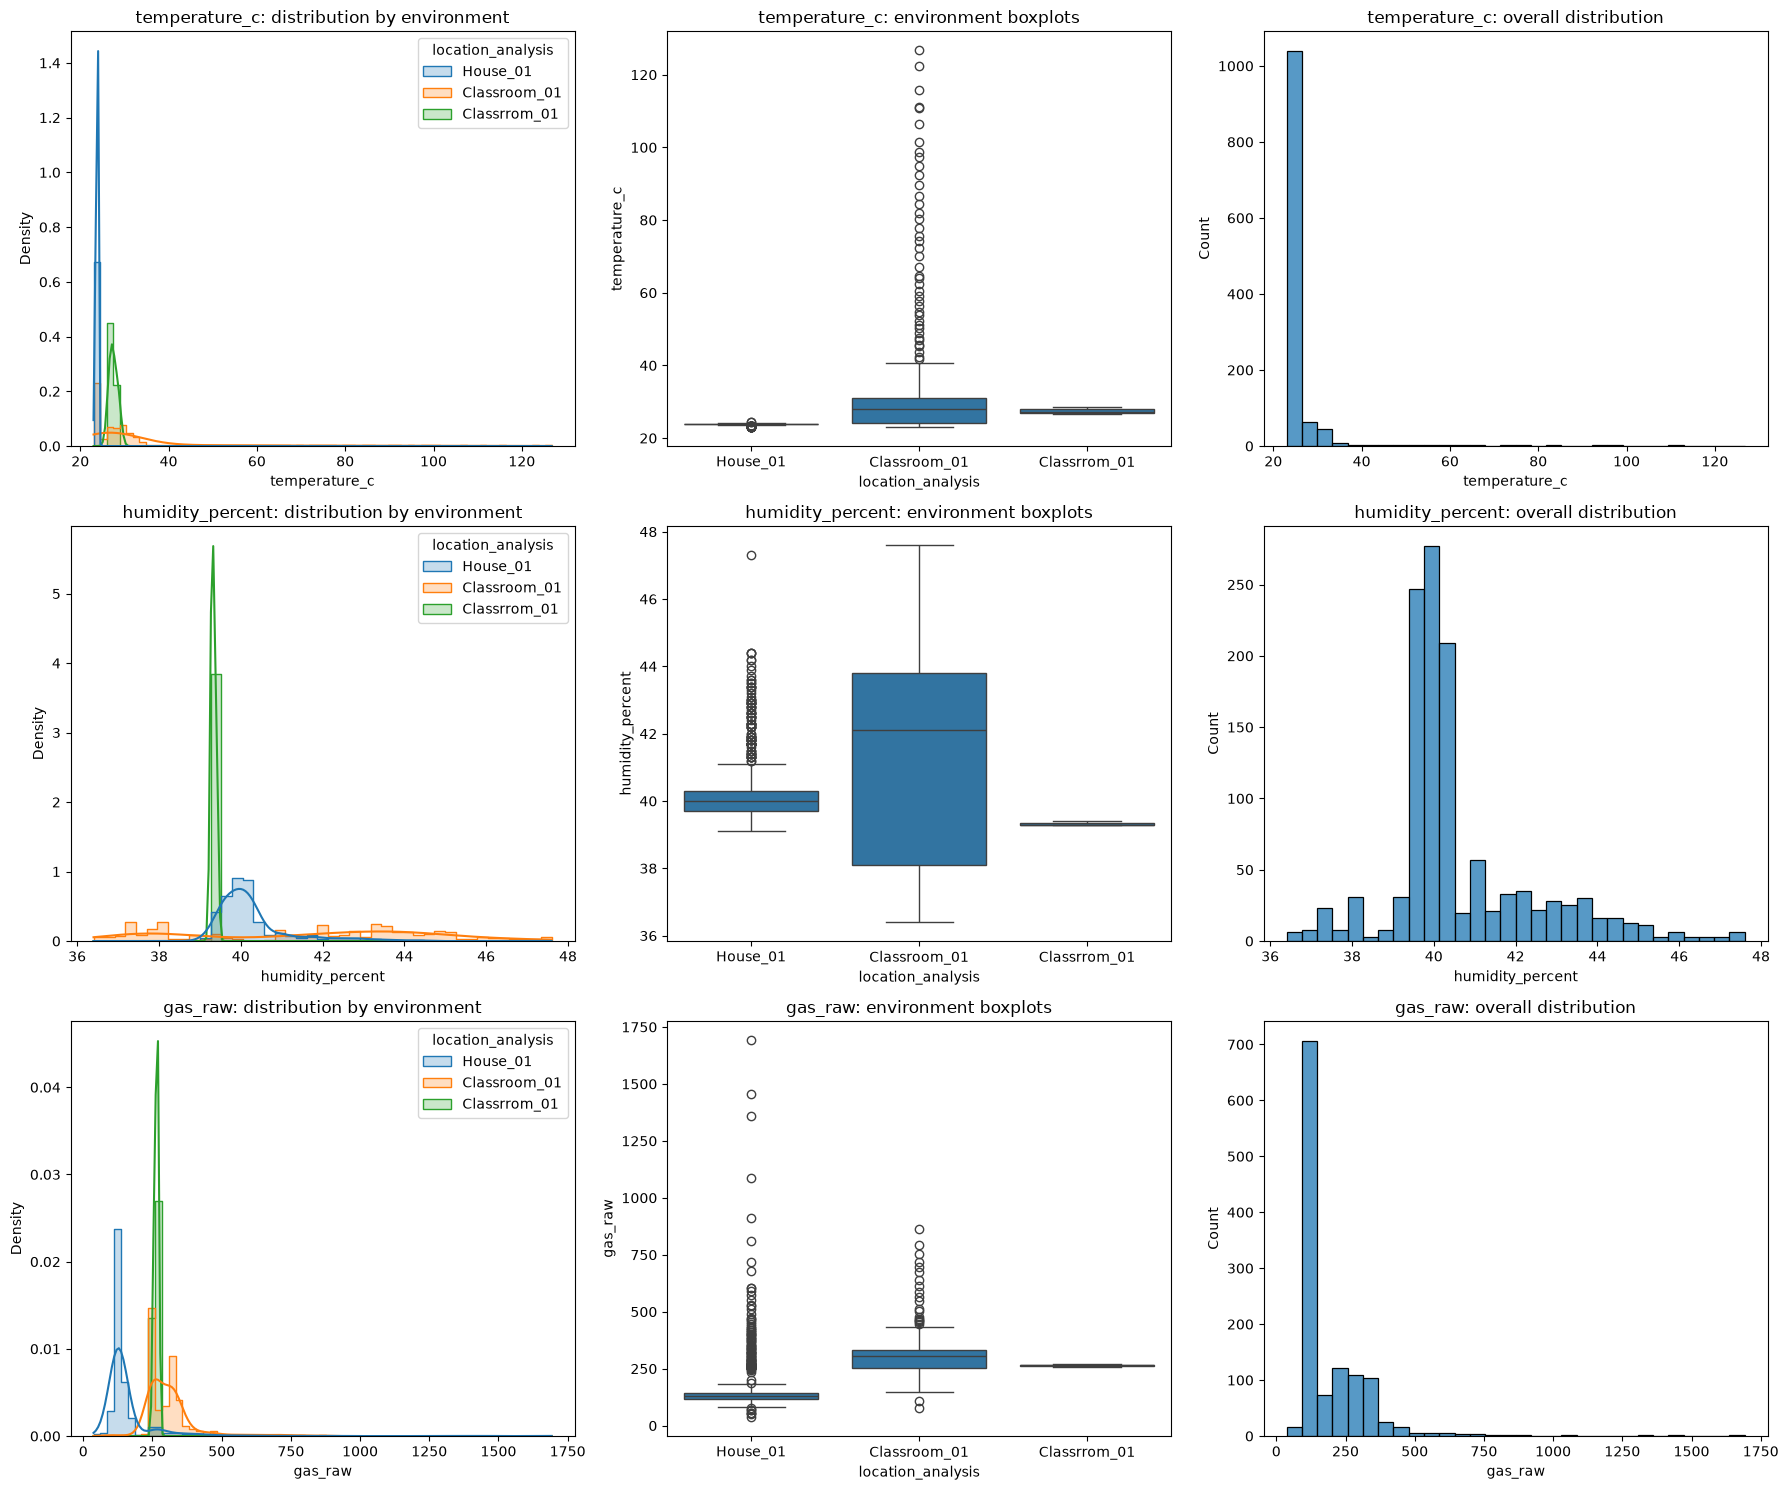

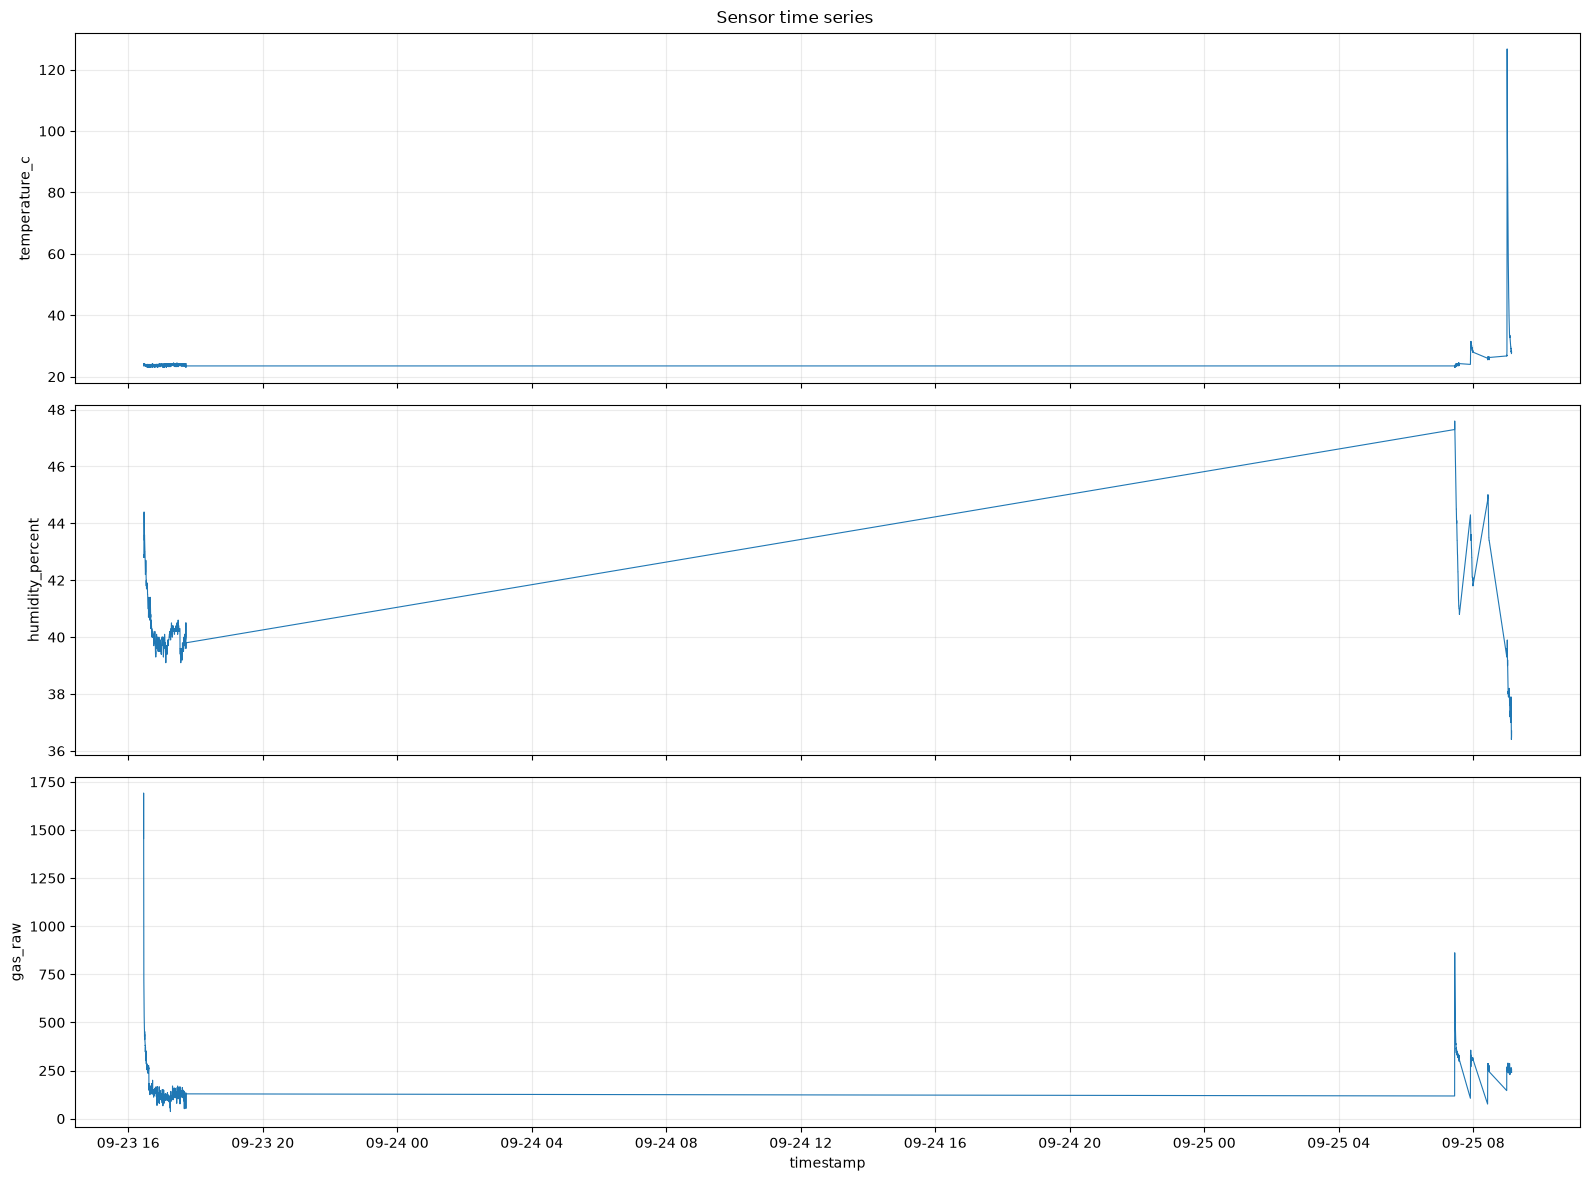


Sensor correlation matrix:
                   temperature_c  humidity_percent   gas_raw
temperature_c          1.000000         -0.178424  0.112903
humidity_percent      -0.178424          1.000000  0.597226
gas_raw                0.112903          0.597226  1.000000


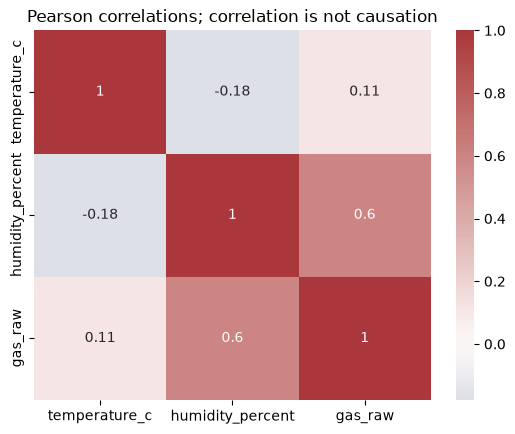

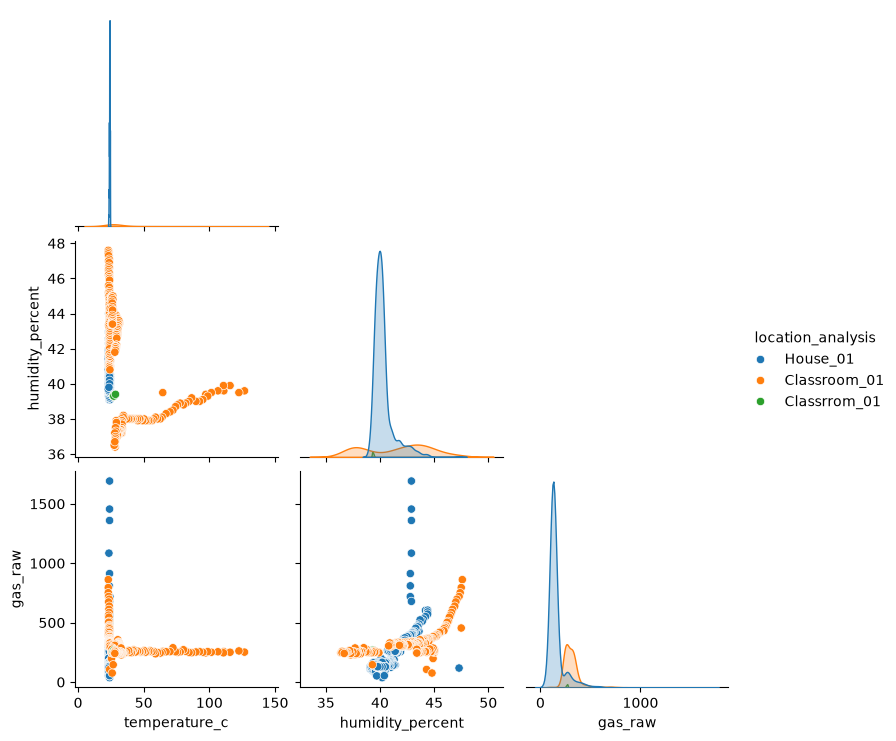


Correlation of first differences:
                          temperature_c_change  humidity_percent_change  \
temperature_c_change                 1.000000                -0.006684   
humidity_percent_change             -0.006684                 1.000000   
gas_raw_change                      -0.003043                -0.092399   

                         gas_raw_change  
temperature_c_change          -0.003043  
humidity_percent_change       -0.092399  
gas_raw_change                 1.000000  

No controlled abnormal-event label is present; abnormal-event phases and earliest detection cannot be estimated from this file.

Wrote processed dataset: ..\testing\csv_data_saving\csv\sensor_data_processed.csv
Wrote analysis report: ..\testing\csv_data_saving\csv\sensor_data_analysis_report.txt


In [22]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

raw_path = Path("../testing/csv_data_saving/csv/sensor_data.csv")
processed_path = Path("../testing/csv_data_saving/csv/sensor_data_processed.csv")
report_path = Path("../testing/csv_data_saving/csv/sensor_data_analysis_report.txt")

raw = pd.read_csv(raw_path)
original_columns = raw.columns.tolist()
analysis = raw.copy()

for column in ["gas_raw", "temperature_c", "humidity_percent"]:
    if column in analysis:
        analysis[column] = pd.to_numeric(analysis[column], errors="coerce")
analysis["timestamp_parsed"] = pd.to_datetime(analysis.get("timestamp"), errors="coerce")
analysis["row_number"] = np.arange(1, len(analysis) + 1)
analysis["location_analysis"] = analysis["location"].astype("string").fillna("unknown") if "location" in analysis else "unknown"
analysis["session_analysis"] = analysis["session_id"].astype("string").fillna("unknown") if "session_id" in analysis else "unknown"
analysis = analysis.sort_values("timestamp_parsed", kind="stable").reset_index(drop=True)
analysis["timestamp_duplicate"] = analysis["timestamp_parsed"].duplicated(keep=False)
analysis["duplicate_row"] = analysis.duplicated(subset=original_columns, keep=False)
analysis["interval_seconds"] = analysis["timestamp_parsed"].diff().dt.total_seconds()
analysis["irregular_interval"] = analysis["interval_seconds"].notna() & ~analysis["interval_seconds"].between(4, 6, inclusive="both")
analysis["gap_over_60_seconds"] = analysis["interval_seconds"].gt(60)
analysis["timestamp_missing_or_invalid"] = analysis["timestamp_parsed"].isna()

sensor_columns = [column for column in ["temperature_c", "humidity_percent", "gas_raw"] if column in analysis]
quality_flags = pd.DataFrame(index=analysis.index)
quality_flags["missing_any_sensor"] = analysis[sensor_columns].isna().any(axis=1)
quality_flags["humidity_out_of_physical_range"] = analysis["humidity_percent"].notna() & ~analysis["humidity_percent"].between(0, 100, inclusive="both") if "humidity_percent" in analysis else False
quality_flags["negative_gas_flag"] = analysis["gas_raw"].lt(0) if "gas_raw" in analysis else False
quality_flags["nonfinite_sensor"] = ~np.isfinite(analysis[sensor_columns].to_numpy(dtype=float)).all(axis=1) if sensor_columns else False
for flag in ["timestamp_missing_or_invalid", "timestamp_duplicate", "duplicate_row", "irregular_interval", "gap_over_60_seconds"]:
    quality_flags[flag] = analysis[flag]
analysis = pd.concat([analysis, quality_flags.add_prefix("quality_")], axis=1)

quality_summary = pd.DataFrame({
    "missing_count": raw.isna().sum(),
    "missing_percent": (raw.isna().mean() * 100).round(3),
    "dtype": raw.dtypes.astype(str),
    "unique_values": raw.nunique(dropna=True),
})
print("Shape:", raw.shape)
print("Columns:", original_columns)
print("Date/time range:", analysis["timestamp_parsed"].min(), "to", analysis["timestamp_parsed"].max())
print("Locations:", analysis["location_analysis"].nunique(), "Sessions:", analysis["session_analysis"].nunique())
print("\nColumn inspection:\n", quality_summary)
print("\nQuality flag totals:\n", analysis.filter(regex="^quality_").sum().sort_values(ascending=False))

interval_distribution = analysis["interval_seconds"].dropna().describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("\nInterval distribution (seconds):\n", interval_distribution)
print("\nMeasurements by location/session:\n", analysis.groupby(["location_analysis", "session_analysis"], dropna=False).size().rename("measurements"))
print("\nMissing by location:\n", raw.assign(location_analysis=analysis["location_analysis"].to_numpy()).groupby("location_analysis", dropna=False).apply(lambda frame: frame.isna().sum(), include_groups=False))
print("\nMissing by session:\n", raw.assign(session_analysis=analysis["session_analysis"].to_numpy()).groupby("session_analysis", dropna=False).apply(lambda frame: frame.isna().sum(), include_groups=False))

if analysis["timestamp_parsed"].notna().any():
    analysis["time_day"] = analysis["timestamp_parsed"].dt.floor("D")
    print("\nMissing values over time:\n", analysis.groupby("time_day", dropna=False)[sensor_columns].apply(lambda frame: frame.isna().sum()))

stats = {}
for sensor in sensor_columns:
    series = analysis[sensor].dropna()
    stats[sensor] = series.describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]).to_dict() | {"variance": series.var(), "IQR": series.quantile(.75) - series.quantile(.25)}
stats_table = pd.DataFrame(stats).T
print("\nSensor statistics:\n", stats_table)

by_environment = analysis.groupby("location_analysis", dropna=False)[sensor_columns].agg(["count", "mean", "median", "std", "min", "max"])
print("\nEnvironment-specific descriptive statistics:\n", by_environment)

fig, axes = plt.subplots(len(sensor_columns), 3, figsize=(18, 5 * len(sensor_columns)), squeeze=False)
for row, sensor in enumerate(sensor_columns):
    sns.histplot(data=analysis, x=sensor, hue="location_analysis", kde=True, ax=axes[row, 0], element="step", stat="density", common_norm=False)
    sns.boxplot(data=analysis, x="location_analysis", y=sensor, ax=axes[row, 1])
    sns.histplot(data=analysis, x=sensor, ax=axes[row, 2], bins=30)
    axes[row, 0].set_title(f"{sensor}: distribution by environment")
    axes[row, 1].set_title(f"{sensor}: environment boxplots")
    axes[row, 2].set_title(f"{sensor}: overall distribution")
plt.tight_layout()
plt.show()

if analysis["timestamp_parsed"].notna().any():
    time_sorted = analysis.sort_values("timestamp_parsed")
    fig, axes = plt.subplots(len(sensor_columns), 1, figsize=(16, 4 * len(sensor_columns)), sharex=True, squeeze=False)
    for row, sensor in enumerate(sensor_columns):
        axes[row, 0].plot(time_sorted["timestamp_parsed"], time_sorted[sensor], linewidth=0.8)
        axes[row, 0].set_ylabel(sensor)
        axes[row, 0].grid(alpha=0.25)
    axes[-1, 0].set_xlabel("timestamp")
    fig.suptitle("Sensor time series")
    plt.tight_layout()
    plt.show()

    indexed = analysis.set_index("timestamp_parsed")
    for sensor in sensor_columns:
        analysis[f"{sensor}_change"] = analysis[sensor].diff()
        analysis[f"{sensor}_rate_per_second"] = analysis[f"{sensor}_change"] / analysis["interval_seconds"]
        for window in ["30s", "1min", "5min"]:
            rolling = indexed[sensor].rolling(window, min_periods=2)
            analysis[f"{sensor}_rolling_{window}_mean"] = rolling.mean().to_numpy()
            analysis[f"{sensor}_rolling_{window}_std"] = rolling.std().to_numpy()
            analysis[f"{sensor}_rolling_{window}_min"] = rolling.min().to_numpy()
            analysis[f"{sensor}_rolling_{window}_max"] = rolling.max().to_numpy()
            analysis[f"{sensor}_rolling_{window}_range"] = (rolling.max() - rolling.min()).to_numpy()

for sensor in sensor_columns:
    q1, q3 = analysis[sensor].quantile([.25, .75])
    iqr = q3 - q1
    analysis[f"{sensor}_robust_outlier_flag"] = (analysis[sensor] < q1 - 1.5 * iqr) | (analysis[sensor] > q3 + 1.5 * iqr)
    analysis[f"{sensor}_isolated_change_flag"] = analysis[f"{sensor}_change"].abs().gt(analysis[f"{sensor}_change"].abs().quantile(.99)) if f"{sensor}_change" in analysis else False

corr = analysis[sensor_columns].corr()
print("\nSensor correlation matrix:\n", corr)
if len(sensor_columns) > 1:
    sns.heatmap(corr, annot=True, cmap="vlag", center=0)
    plt.title("Pearson correlations; correlation is not causation")
    plt.show()
    sns.pairplot(analysis[sensor_columns + ["location_analysis"]], hue="location_analysis", corner=True)
    plt.show()

change_columns = [f"{sensor}_change" for sensor in sensor_columns if f"{sensor}_change" in analysis]
if len(change_columns) > 1:
    print("\nCorrelation of first differences:\n", analysis[change_columns].corr())

for sensor in sensor_columns:
    baseline = analysis.groupby("location_analysis")[sensor].transform("median")
    baseline_std = analysis.groupby("location_analysis")[sensor].transform("std").replace(0, np.nan)
    analysis[f"{sensor}_baseline_median"] = baseline
    analysis[f"{sensor}_baseline_robust_deviation"] = (analysis[sensor] - baseline) / baseline_std
    analysis[f"{sensor}_baseline_q01"] = analysis.groupby("location_analysis")[sensor].transform(lambda series: series.quantile(.01))
    analysis[f"{sensor}_baseline_q99"] = analysis.groupby("location_analysis")[sensor].transform(lambda series: series.quantile(.99))

analysis["startup_warmup_first_60s"] = False
if analysis["timestamp_parsed"].notna().any():
    first_timestamp = analysis["timestamp_parsed"].min()
    analysis["startup_warmup_first_60s"] = analysis["timestamp_parsed"].le(first_timestamp + pd.Timedelta(seconds=60))
analysis["constant_sensor_run_flag"] = False
for sensor in sensor_columns:
    analysis["constant_sensor_run_flag"] |= analysis[sensor].eq(analysis[sensor].shift()).rolling(12, min_periods=12).sum().eq(12)

if "event" in analysis.columns or "label" in analysis.columns:
    event_column = "event" if "event" in analysis.columns else "label"
    print(f"\nEvent labels found in '{event_column}'. Analyze each label/session separately before baseline fitting.")
else:
    print("\nNo controlled abnormal-event label is present; abnormal-event phases and earliest detection cannot be estimated from this file.")

analysis.to_csv(processed_path, index=False)
report_lines = [
    "Sensor data analysis report", "", f"Raw shape: {raw.shape}", f"Original columns: {original_columns}",
    f"Time range: {analysis['timestamp_parsed'].min()} to {analysis['timestamp_parsed'].max()}",
    f"Locations: {analysis['location_analysis'].nunique()} (source location column present: {'location' in raw})",
    f"Sessions: {analysis['session_analysis'].nunique()} (source session_id column present: {'session_id' in raw})",
    "", "Observed quality flags:", analysis.filter(regex="^quality_").sum().to_string(),
    "", "Interpretation and decisions:",
    "- Raw data is preserved unchanged.",
    "- No observation is deleted or sensor value imputed.",
    "- Invalid timestamps, duplicate rows, gaps, negative gas values, and humidity range violations are flagged for review.",
    "- IQR and 99th-percentile first-difference flags identify candidates; they are not proof of invalidity and are retained.",
    "- The first 60 seconds are marked as a warm-up candidate only; confirm against sensor specifications and repeated runs.",
    "- Current data has no event labels, so abnormal-event detection timing and risk classes cannot be validated.",
    "", "Modeling recommendations:",
    "- Split by session, experiment, day, and hold out at least one unseen location when possible; never randomly split adjacent rows.",
    "- Compare raw values, rates, rolling variability/range, and location-specific baseline deviations.",
    "- Fit baselines only on reviewed normal data; do not use the full stream if it contains events.",
    "- Use recall-sensitive evaluation for high-risk events while tracking false alarms per hour.",
]
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print(f"\nWrote processed dataset: {processed_path}")
print(f"Wrote analysis report: {report_path}")

## Findings, limitations, and modeling recommendations

### Dataset overview and data quality

The updated source contains 1,062 observations and eight columns: the four sensor/time columns plus `anomaly_detected`, `location`, `experiment_stage`, and `is_experiment`. It spans 2026-09-23 16:27:19 to 2026-09-25 07:59:24. The data contains 905 `House_01` rows and 157 `Classroom_01` rows, but no session identifier.

The 5-second cadence is typical for most observations: the median, Q1, Q3, and 95th percentile interval are 5 seconds. It is not continuous: 43 timestamps are duplicated, 46 intervals are outside 4-6 seconds, 4 gaps exceed 60 seconds, and 7 exact duplicate rows are present. No missing values, invalid timestamps, negative gas readings, non-finite sensor values, or humidity values outside 0-100% were found. These checks do not establish that a gas value is physically correct because sensor specifications and calibration are not included.

No rows were removed and no sensor values were imputed or changed. Duplicate, gap, irregularity, robust-outlier, isolated-change, constant-run, and first-60-second warm-up candidate flags remain in the processed dataset.

### Sensor behavior and environment differences

Across all rows, temperature has median 24.0 C, humidity 40.1%, and gas 130. The gas distribution is right-skewed. Normal-only baselines exclude `anomaly_detected=True` and `is_experiment=True`: House_01 has temperature/humidity/gas medians of 23.75 C, 40.0%, and 128; Classroom_01 has 24.0 C, 43.6%, and 338. Classroom temperature is also substantially more variable. These observed differences support location-specific baselines and make a universal raw gas threshold inappropriate for this dataset, although more sessions and repeated experiments are needed.

Humidity and gas have Pearson correlation near 0.78 overall. This is an observation, not evidence of causation, and may reflect time trends, location composition, or activity. First-difference correlations are near zero, so level correlation should not be confused with synchronized changes.

### Labeled anomalies and experiments

There are 87 anomaly-labeled rows and 50 experiment rows. All 50 experiment rows occur in Classroom_01 and are also anomaly-labeled. House_01 has 37 anomaly-labeled rows outside the experiment subset. In the labeled summaries, Classroom experiment rows have temperature mean about 29.6 C, while House normal rows have gas median 128 and House anomaly rows have gas median 466. These are useful observed contrasts, not universal fire rules or causal conclusions.

All `experiment_stage` values are blank/`None`, so before/developing/high-risk/recovery timing and earliest distinguishability cannot yet be estimated. Add populated stage and experiment identifiers before evaluating detection delay or event progression.

### Baselines and modeling recommendations

Compare mean plus standard deviation, median plus IQR, percentile bands, and robust z-scores per location. Mean-based bands are simple but sensitive to events and skew; median/IQR is more robust; percentile bands handle asymmetric tails; robust z-scores make different sensors comparable. Fit baselines only on reviewed normal data, as implemented in the labeled analysis section.

Retain raw sensor values, sampling interval, first differences, rates per second, rolling means and variability/ranges, location-specific baseline deviations, and sensor combinations. Do not discard nonlinear or temporally useful features based only on pairwise correlation.

Use session-, experiment-, day-, and location-aware splits. Train on reviewed normal data and selected labeled events, validate on held-out sessions/days, and test on at least one unseen session and preferably one unseen location. Random row-level splitting leaks neighboring measurements from the same event into both partitions and can make detection and false-alarm performance look overly optimistic. Evaluate high-risk recall, detection delay, false alarms per hour, and calibration.

The processed CSV and audit report are written beside the raw CSV. The raw CSV is never overwritten.

## Labeled location and experiment analysis

The CSV now includes `anomaly_detected`, `location`, `experiment_stage`, and `is_experiment`. This section uses those labels explicitly. Baselines exclude rows marked anomalous or experimental, and labeled event rows are summarized separately. Labels are treated as annotations for analysis, not as proof that a sensor change caused an event.

Labeled locations:
 location_analysis
House_01        905
Classroom_01    294
Classrrom_01      3
Name: count, dtype: Int64

Anomaly labels:
 anomaly_label
False    1038
True      164
Name: count, dtype: int64

Experiment labels:
 experiment_label
False    1050
True      152
Name: count, dtype: int64

Experiment stages:
 stage_label
unlabeled           1049
System_Resetting     114
Active                26
Start                  7
Finishing              6
Name: count, dtype: Int64

Location by anomaly label:
 anomaly_label      False  True 
location_analysis              
Classroom_01         167    127
Classrrom_01           3      0
House_01             868     37

Location by experiment label:
 experiment_label   False  True 
location_analysis              
Classroom_01         145    149
Classrrom_01           0      3
House_01             905      0

Rows available for normal baseline: 1013 of 1202

Normal-only baseline by location:
                   temperature_c                

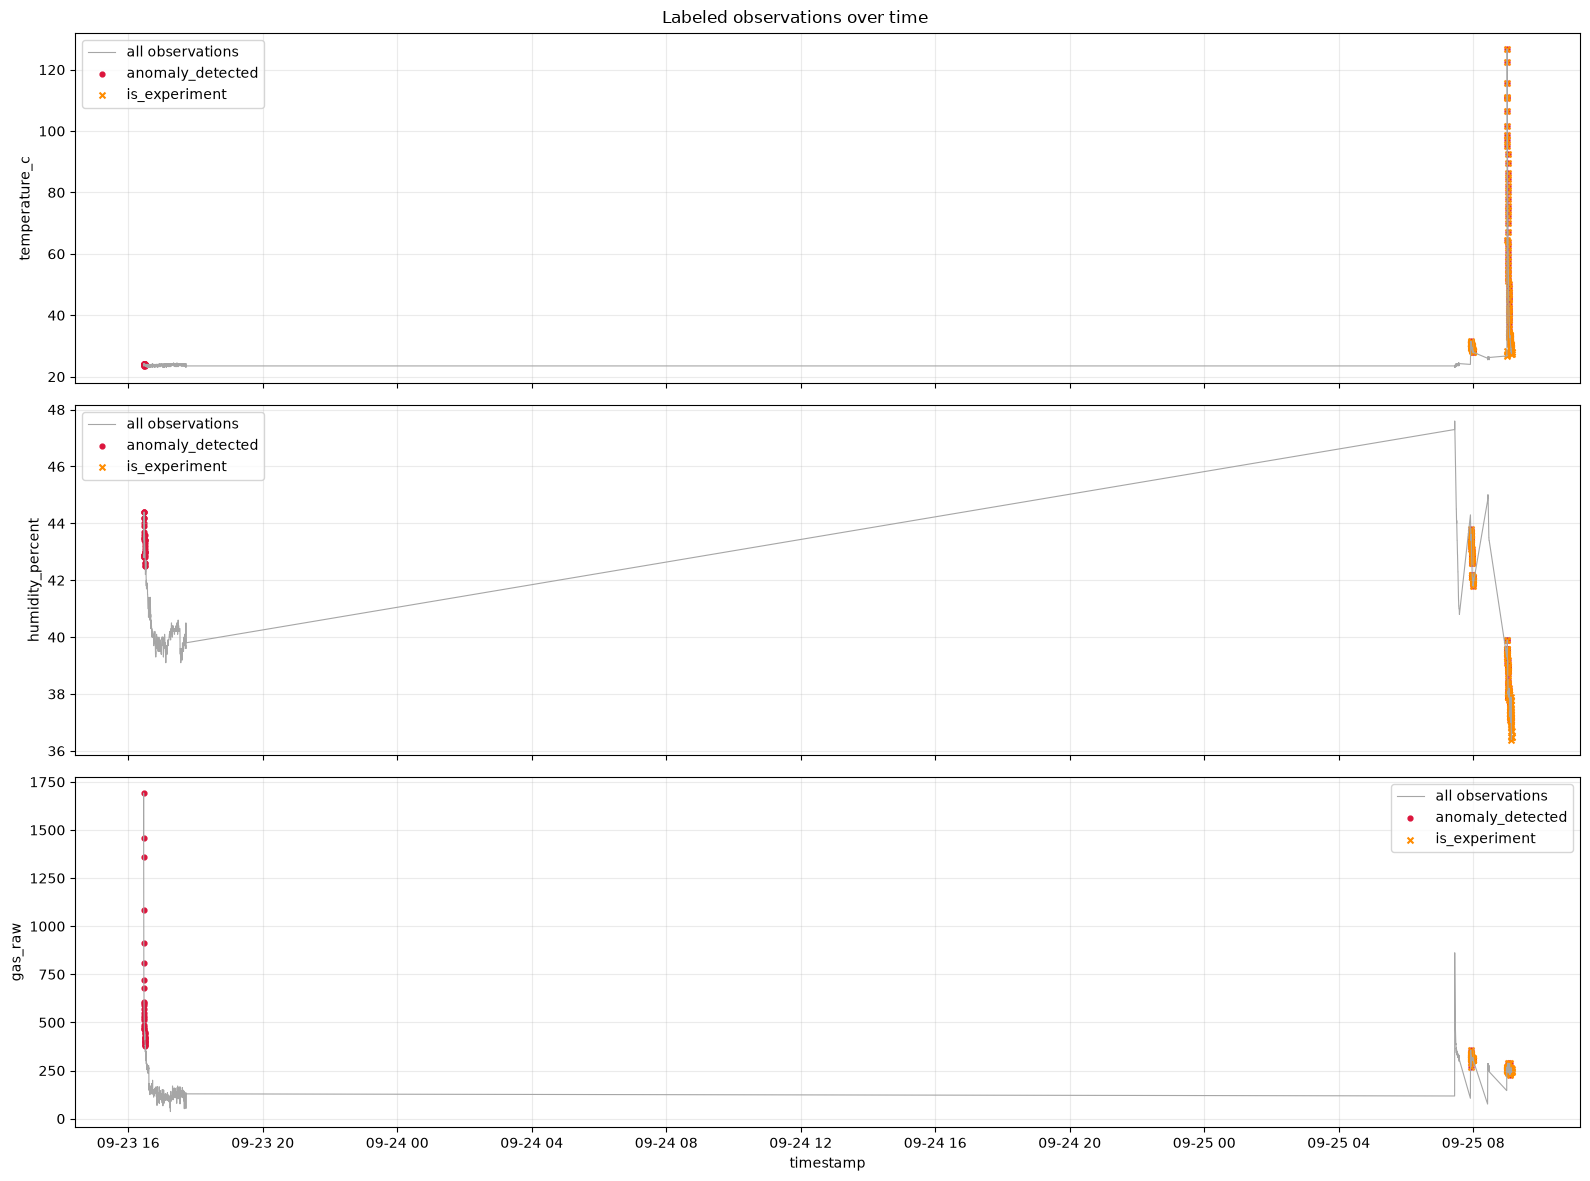

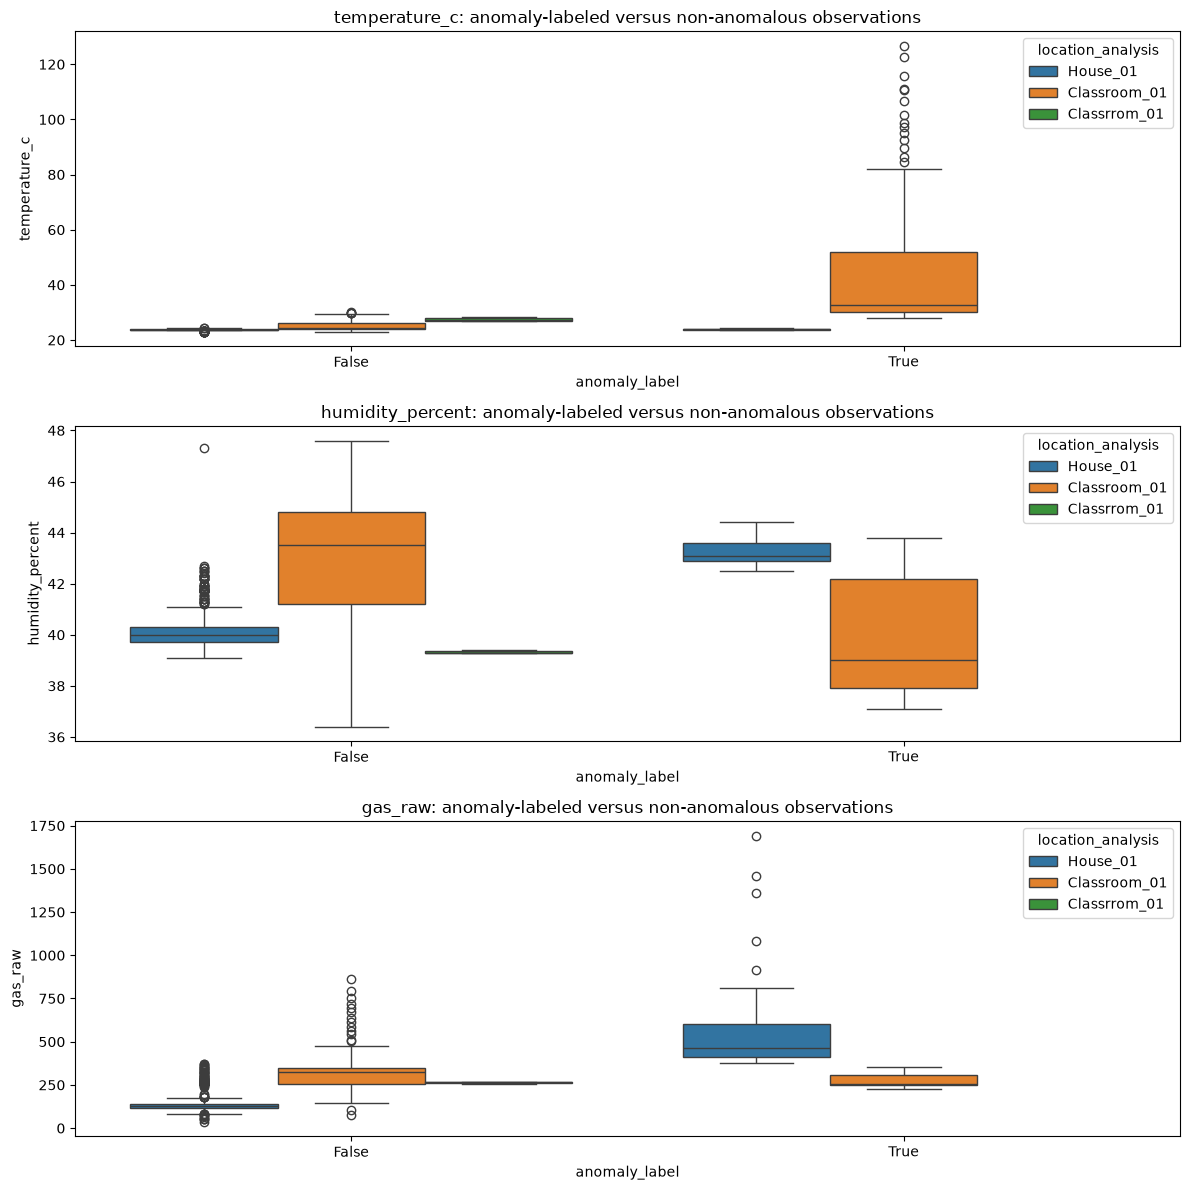


Stage-specific analysis is available above because experiment_stage contains labeled values.

Updated processed dataset and report using labeled columns: ..\testing\csv_data_saving\csv\sensor_data_processed.csv


In [23]:
labeled = analysis.copy()
labeled["location_analysis"] = labeled["location_analysis"].astype("string").fillna("unknown")
labeled["anomaly_label"] = labeled["anomaly_detected"].astype("string").str.strip().str.lower().map({"true": True, "false": False, "1": True, "0": False}) if "anomaly_detected" in labeled else False
labeled["experiment_label"] = labeled["is_experiment"].astype("string").str.strip().str.lower().map({"true": True, "false": False, "1": True, "0": False}) if "is_experiment" in labeled else False
labeled["stage_label"] = labeled["experiment_stage"].astype("string").replace({"None": pd.NA, "nan": pd.NA, "": pd.NA}).fillna("unlabeled") if "experiment_stage" in labeled else "unlabeled"

print("Labeled locations:\n", labeled["location_analysis"].value_counts(dropna=False))
print("\nAnomaly labels:\n", labeled["anomaly_label"].value_counts(dropna=False))
print("\nExperiment labels:\n", labeled["experiment_label"].value_counts(dropna=False))
print("\nExperiment stages:\n", labeled["stage_label"].value_counts(dropna=False))
print("\nLocation by anomaly label:\n", pd.crosstab(labeled["location_analysis"], labeled["anomaly_label"], dropna=False))
print("\nLocation by experiment label:\n", pd.crosstab(labeled["location_analysis"], labeled["experiment_label"], dropna=False))

normal_mask = labeled["anomaly_label"].eq(False) & labeled["experiment_label"].eq(False)
normal_rows = labeled.loc[normal_mask]
print(f"\nRows available for normal baseline: {len(normal_rows)} of {len(labeled)}")
normal_baseline = normal_rows.groupby("location_analysis", dropna=False)[sensor_columns].agg(["count", "mean", "median", "std", "min", "max"])
print("\nNormal-only baseline by location:\n", normal_baseline)

labeled_summary = labeled.groupby(["location_analysis", "anomaly_label", "experiment_label", "stage_label"], dropna=False)[sensor_columns].agg(["count", "mean", "median", "std", "min", "max"])
print("\nSensor behavior by location, anomaly, experiment, and stage:\n", labeled_summary)

for sensor in sensor_columns:
    normal_median = normal_rows.groupby("location_analysis")[sensor].transform("median")
    normal_std = normal_rows.groupby("location_analysis")[sensor].transform("std").replace(0, np.nan)
    normal_rows[f"{sensor}_normal_baseline_median"] = normal_median
    normal_rows[f"{sensor}_normal_baseline_z"] = (normal_rows[sensor] - normal_median) / normal_std
    labeled[f"{sensor}_normal_baseline_median"] = labeled["location_analysis"].map(normal_rows.groupby("location_analysis")[sensor].median())
    labeled[f"{sensor}_normal_baseline_z"] = (labeled[sensor] - labeled[f"{sensor}_normal_baseline_median"]) / labeled["location_analysis"].map(normal_rows.groupby("location_analysis")[sensor].std().replace(0, np.nan))

if labeled["anomaly_label"].notna().any():
    fig, axes = plt.subplots(len(sensor_columns), 1, figsize=(16, 4 * len(sensor_columns)), sharex=True, squeeze=False)
    for row, sensor in enumerate(sensor_columns):
        axes[row, 0].plot(labeled["timestamp_parsed"], labeled[sensor], color="0.65", linewidth=0.8, label="all observations")
        anomaly_rows = labeled["anomaly_label"].eq(True)
        axes[row, 0].scatter(labeled.loc[anomaly_rows, "timestamp_parsed"], labeled.loc[anomaly_rows, sensor], color="crimson", s=12, label="anomaly_detected")
        experiment_rows = labeled["experiment_label"].eq(True)
        axes[row, 0].scatter(labeled.loc[experiment_rows, "timestamp_parsed"], labeled.loc[experiment_rows, sensor], color="darkorange", s=18, marker="x", label="is_experiment")
        axes[row, 0].set_ylabel(sensor)
        axes[row, 0].grid(alpha=0.25)
        axes[row, 0].legend(loc="best")
    axes[-1, 0].set_xlabel("timestamp")
    fig.suptitle("Labeled observations over time")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(len(sensor_columns), 1, figsize=(12, 4 * len(sensor_columns)), squeeze=False)
    for row, sensor in enumerate(sensor_columns):
        sns.boxplot(data=labeled, x="anomaly_label", y=sensor, hue="location_analysis", ax=axes[row, 0])
        axes[row, 0].set_title(f"{sensor}: anomaly-labeled versus non-anomalous observations")
    plt.tight_layout()
    plt.show()

if labeled["stage_label"].ne("unlabeled").any():
    print("\nStage-specific analysis is available above because experiment_stage contains labeled values.")
else:
    print("\nAll experiment_stage values are blank/None; add phase labels such as before, developing, high_risk, and recovery for event-timing analysis.")

labeled.to_csv(processed_path, index=False)
report_lines = [
    "", "Updated labeled analysis:",
    f"- Locations observed: {labeled['location_analysis'].nunique()}.",
    f"- Anomaly-labeled rows: {int(labeled['anomaly_label'].eq(True).sum())}; unlabeled anomaly rows: {int(labeled['anomaly_label'].isna().sum())}.",
    f"- Experiment rows: {int(labeled['experiment_label'].eq(True).sum())}; experiment stages with values: {int(labeled['stage_label'].ne('unlabeled').sum())}.",
    f"- Normal baseline rows: {len(normal_rows)}; baseline excludes anomaly_detected=True and is_experiment=True.",
    "- Baseline-relative columns are calculated per location from normal-only data.",
    "- Anomaly and experiment labels are observational annotations; they do not establish causation or a universal fire threshold.",
    "- Add session_id, experiment_id, and populated experiment_stage values before estimating detection delay or event phases.",
]
report_path.write_text(report_path.read_text(encoding="utf-8") + "\n" + "\n".join(report_lines), encoding="utf-8")
print(f"\nUpdated processed dataset and report using labeled columns: {processed_path}")

## Risk-level model comparison and training

This section predicts the normalized `threat_level` label (`Low`, `Medium`, or `High`) from sensor readings and their changes/rates. It compares logistic regression, random forest, extra trees, and support vector classification using expanding-window validation, tunes the strongest candidate, evaluates it on a later chronological holdout, and saves the fitted pipeline under `models/`. Label columns and collection context are not model inputs. The temperature input/cleaning ceiling is 600 C. At inference, temperatures above the highest labeled training temperature trigger an explicit fail-safe High result because the model cannot reliably extrapolate beyond its training data.

In [45]:
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, make_scorer, recall_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

raw_path = Path("../testing/csv_data_saving/csv/sensor_data.csv")
model_path = Path("../models/risk_level_model.joblib")
risk_labels = ["Low", "Medium", "High"]
sensor_columns = ["gas_raw", "temperature_c", "humidity_percent"]
max_valid_temperature_c = 600.0
feature_columns = sensor_columns + [
    "gas_raw_delta", "temperature_c_delta", "humidity_percent_delta",
    "gas_raw_rate", "temperature_c_rate", "humidity_percent_rate",
]

risk_data = pd.read_csv(raw_path)
risk_data["timestamp"] = pd.to_datetime(risk_data["timestamp"], errors="coerce")
for column in sensor_columns:
    risk_data[column] = pd.to_numeric(risk_data[column], errors="coerce")
risk_data["risk_level"] = (
    risk_data["threat_level"]
    .astype("string")
    .str.strip()
    .str.casefold()
    .map({"low": "Low", "medium": "Medium", "high": "High"})
)
risk_data = risk_data.dropna(subset=["timestamp", "risk_level"] + sensor_columns)
valid_sensor_mask = (
    risk_data["gas_raw"].between(0, 4096)
    & risk_data["temperature_c"].between(-40, max_valid_temperature_c)
    & risk_data["humidity_percent"].between(0, 100)
)
risk_data = risk_data.loc[valid_sensor_mask].drop_duplicates().copy()
risk_data = risk_data.sort_values("timestamp", kind="stable").reset_index(drop=True)

risk_data["elapsed_seconds"] = risk_data["timestamp"].diff().dt.total_seconds().clip(lower=1)
for column in sensor_columns:
    risk_data[f"{column}_delta"] = risk_data[column].diff()
    risk_data[f"{column}_rate"] = risk_data[f"{column}_delta"] / risk_data["elapsed_seconds"]
risk_data[feature_columns] = risk_data[feature_columns].replace([np.inf, -np.inf], np.nan)
risk_data = risk_data.dropna(subset=["risk_level"]).reset_index(drop=True)

print("Usable rows:", len(risk_data))
print("Risk-level counts:\n", risk_data["risk_level"].value_counts().reindex(risk_labels, fill_value=0))
print("Time range:", risk_data["timestamp"].min(), "to", risk_data["timestamp"].max())
print("Maximum accepted temperature:", max_valid_temperature_c, "C")

split_index = int(len(risk_data) * 0.8)
train_data = risk_data.iloc[:split_index].copy()
test_data = risk_data.iloc[split_index:].copy()
X_train, y_train = train_data[feature_columns], train_data["risk_level"]
X_test, y_test = test_data[feature_columns], test_data["risk_level"]

if set(y_train.unique()) != set(risk_labels) or set(y_test.unique()) != set(risk_labels):
    raise ValueError(
        "Both chronological partitions must contain Low, Medium, and High. "
        "Collect more labeled examples or adjust the time-based holdout before comparing models."
    )

time_splitter = TimeSeriesSplit(n_splits=4, gap=1)
cv_splits = [
    (train_indices, validation_indices)
    for train_indices, validation_indices in time_splitter.split(X_train)
    if y_train.iloc[train_indices].nunique() >= 2
]
if len(cv_splits) < 2:
    raise ValueError("Not enough time-ordered training data for at least two valid CV folds.")

macro_f1_scorer = make_scorer(
    f1_score, labels=risk_labels, average="macro", zero_division=0
)
high_recall_scorer = make_scorer(
    recall_score, labels=["High"], average="macro", zero_division=0
)
scoring = {"macro_f1": macro_f1_scorer, "high_recall": high_recall_scorer}

candidate_models = {
    "Logistic Regression": make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
    ),
    "Random Forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(n_estimators=300, class_weight="balanced", min_samples_leaf=2, random_state=42, n_jobs=-1),
    ),
    "Extra Trees": make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesClassifier(n_estimators=300, class_weight="balanced", min_samples_leaf=2, random_state=42, n_jobs=-1),
    ),
    "Support Vector Machine": make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler(),
        SVC(class_weight="balanced", probability=True, random_state=42),
    ),
}

comparison_rows = []
for model_name, estimator in candidate_models.items():
    scores = cross_validate(estimator, X_train, y_train, cv=cv_splits, scoring=scoring, n_jobs=1, error_score="raise")
    comparison_rows.append({
        "model": model_name,
        "cv_macro_f1": scores["test_macro_f1"].mean(),
        "cv_high_recall": scores["test_high_recall"].mean(),
    })

comparison = pd.DataFrame(comparison_rows).sort_values(
    ["cv_macro_f1", "cv_high_recall"], ascending=False
).reset_index(drop=True)
print("\nExpanding-window model comparison (training data only):\n", comparison.to_string(index=False))
best_model_name = comparison.loc[0, "model"]
best_estimator = candidate_models[best_model_name]
print("\nSelected model for tuning:", best_model_name)

search_spaces = {
    "Logistic Regression": {
        "logisticregression__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
        "logisticregression__class_weight": ["balanced", None],
    },
    "Random Forest": {
        "randomforestclassifier__n_estimators": [200, 400, 600],
        "randomforestclassifier__max_depth": [None, 6, 10, 16],
        "randomforestclassifier__min_samples_leaf": [1, 2, 4, 8],
        "randomforestclassifier__max_features": ["sqrt", 0.8, 1.0],
        "randomforestclassifier__class_weight": ["balanced", "balanced_subsample", None],
    },
    "Extra Trees": {
        "extratreesclassifier__n_estimators": [200, 400, 600],
        "extratreesclassifier__max_depth": [None, 6, 10, 16],
        "extratreesclassifier__min_samples_leaf": [1, 2, 4, 8],
        "extratreesclassifier__max_features": ["sqrt", 0.8, 1.0],
        "extratreesclassifier__class_weight": ["balanced", "balanced_subsample", None],
    },
    "Support Vector Machine": {
        "svc__C": [0.1, 0.3, 1, 3, 10, 30],
        "svc__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
        "svc__kernel": ["rbf", "linear"],
        "svc__class_weight": ["balanced", None],
    },
}

search = RandomizedSearchCV(
    estimator=best_estimator,
    param_distributions=search_spaces[best_model_name],
    n_iter=12, scoring=macro_f1_scorer, cv=cv_splits, refit=True,
    random_state=42, n_jobs=1, error_score="raise",
)
search.fit(X_train, y_train)
risk_model = search.best_estimator_
print("\nBest CV macro F1 after tuning:", round(search.best_score_, 3))
print("Best parameters:", search.best_params_)

test_predictions = risk_model.predict(X_test)
print("\nFinal chronological holdout results:")
print("Holdout period:", test_data["timestamp"].min(), "to", test_data["timestamp"].max())
print("Confusion matrix (rows=true, columns=predicted; Low, Medium, High):\n",
      confusion_matrix(y_test, test_predictions, labels=risk_labels))
print("\nPer-class report:\n",
      classification_report(y_test, test_predictions, labels=risk_labels, zero_division=0))

risk_model.fit(risk_data[feature_columns], risk_data["risk_level"])
temperature_training_max_c = float(risk_data["temperature_c"].max())
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({
    "model": risk_model,
    "feature_columns": feature_columns,
    "risk_labels": risk_labels,
    "model_name": best_model_name,
    "max_valid_temperature_c": max_valid_temperature_c,
    "temperature_training_max_c": temperature_training_max_c,
}, model_path)
print("Saved final model fitted on all labeled rows:", model_path.resolve())
print("Highest temperature observed in labeled training data:", temperature_training_max_c, "C")

Usable rows: 1198
Risk-level counts:
 risk_level
Low       1050
Medium      86
High        62
Name: count, dtype: int64
Time range: 2026-09-23 16:27:19 to 2026-09-25 09:08:24
Maximum accepted temperature: 600.0 C


c:\Users\jeron\OneDrive\Proyectos\supervized-ML-fire-alarm\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\jeron\OneDrive\Proyectos\supervized-ML-fire-alarm\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\jeron\OneDrive\Proyectos\supervized-ML-fire-alarm\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\jeron\OneDrive\Proyectos\supervized-ML-fire-al


Expanding-window model comparison (training data only):
                  model  cv_macro_f1  cv_high_recall
         Random Forest     0.324663             0.0
Support Vector Machine     0.320202             0.0
   Logistic Regression     0.318718             0.0
           Extra Trees     0.318718             0.0

Selected model for tuning: Random Forest

Best CV macro F1 after tuning: 0.326
Best parameters: {'randomforestclassifier__n_estimators': 400, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__max_features': 1.0, 'randomforestclassifier__max_depth': 16, 'randomforestclassifier__class_weight': None}

Final chronological holdout results:
Holdout period: 2026-09-25 07:31:36 to 2026-09-25 09:08:24
Confusion matrix (rows=true, columns=predicted; Low, Medium, High):
 [[129   0   0]
 [ 65   0   0]
 [ 46   0   0]]

Per-class report:
               precision    recall  f1-score   support

         Low       0.54      1.00      0.70       129
      Medium       

In [46]:
from pathlib import Path
import joblib
import pandas as pd

model_bundle_path = Path("../models/risk_level_model.joblib")
model_bundle = joblib.load(model_bundle_path)
saved_risk_model = model_bundle["model"]
saved_feature_columns = model_bundle["feature_columns"]
max_valid_temperature_c = model_bundle["max_valid_temperature_c"]
temperature_training_max_c = model_bundle["temperature_training_max_c"]

def predict_risk_manual(
    gas_raw=None,
    temperature_c=None,
    humidity_percent=None,
    previous_reading=None,
    elapsed_seconds=5.0,
    model=saved_risk_model,
    feature_names=saved_feature_columns,
 ):
    """Predict risk manually; temperatures beyond labeled training data fail safe to High."""
    if gas_raw is None:
        gas_raw = float(input("Gas raw: "))
    if temperature_c is None:
        temperature_c = float(input("Temperature (C): "))
    if humidity_percent is None:
        humidity_percent = float(input("Humidity (%): "))

    current = {
        "gas_raw": float(gas_raw),
        "temperature_c": float(temperature_c),
        "humidity_percent": float(humidity_percent),
    }
    if not 0 <= current["gas_raw"] <= 4096:
        raise ValueError("gas_raw must be between 0 and 4096.")
    if not -40 <= current["temperature_c"] <= max_valid_temperature_c:
        raise ValueError(f"temperature_c must be between -40 and {max_valid_temperature_c} C.")
    if not 0 <= current["humidity_percent"] <= 100:
        raise ValueError("humidity_percent must be between 0 and 100.")

    features = current.copy()
    if previous_reading is None:
        for sensor in current:
            features[f"{sensor}_delta"] = 0.0
            features[f"{sensor}_rate"] = 0.0
    else:
        elapsed_seconds = float(elapsed_seconds)
        if elapsed_seconds <= 0:
            raise ValueError("elapsed_seconds must be greater than zero.")
        for sensor, value in current.items():
            delta = value - float(previous_reading[sensor])
            features[f"{sensor}_delta"] = delta
            features[f"{sensor}_rate"] = delta / elapsed_seconds

    feature_row = pd.DataFrame([features], columns=feature_names)
    model_prediction = model.predict(feature_row)[0]
    temperature_out_of_training_range = current["temperature_c"] > temperature_training_max_c
    final_risk = "High" if temperature_out_of_training_range else model_prediction
    result = {
        "risk_level": final_risk,
        "model_prediction": model_prediction,
        "temperature_out_of_training_range": temperature_out_of_training_range,
    }

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(feature_row)[0]
        result["probabilities"] = dict(zip(model.classes_, probabilities))
        print("Model prediction:", model_prediction)
        print("Final risk:", final_risk)
        print("Class probabilities:", {key: round(value, 3) for key, value in result["probabilities"].items()})
    else:
        print("Final risk:", final_risk)

    if temperature_out_of_training_range:
        print(
            "Fail-safe override: temperature exceeds the highest labeled training value "
            f"({temperature_training_max_c:.2f} C); model output is outside its training range."
        )
    return result

### Test a reading manually

Run the function cell to load the saved model. Edit the example values in the following cell and run it to test a reading. Calling `predict_risk_manual()` without arguments prompts for the three sensor values; pass `previous_reading` and `elapsed_seconds` to include deltas and rates. The first sample defaults those temporal features to zero.

In [86]:
# Edit these values to try other sensor readings.
prediction = predict_risk_manual(
    gas_raw=300,
    temperature_c=30.0,
    humidity_percent=42.9,
)


Model prediction: Medium
Final risk: Medium
Class probabilities: {'High': np.float64(0.0), 'Low': np.float64(0.007), 'Medium': np.float64(0.993)}
